In [1]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

# Machine Learning
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Classification Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

# Save Model
import joblib

In [5]:
df = pd.read_csv("data.csv", encoding="latin1")

In [6]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [7]:
df.tail()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,12/9/2011 12:50,4.95,12680.0,France


In [8]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 541909
Columns : 8


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Quantity,541909.0,9.552250,218.081158,-80995.00,1.00,3.00,10.00,80995.0
UnitPrice,541909.0,4.611114,96.759853,-11062.06,1.25,2.08,4.13,38970.0
CustomerID,406829.0,15287.690570,1713.600303,12346.00,13953.00,15152.00,16791.00,18287.0


In [11]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 541909
Columns: 8


In [12]:
df.columns.tolist()

['InvoiceNo',
 'StockCode',
 'Description',
 'Quantity',
 'InvoiceDate',
 'UnitPrice',
 'CustomerID',
 'Country']

In [14]:
df.dtypes

,0
InvoiceNo,object
StockCode,object
Description,object
Quantity,int64
InvoiceDate,object
UnitPrice,float64
CustomerID,float64
Country,object


In [15]:
missing = df.isnull().sum().sort_values(ascending=False)
missing

,0
CustomerID,135080
Description,1454
StockCode,0
InvoiceNo,0
Quantity,0
InvoiceDate,0
UnitPrice,0
Country,0


In [16]:
missing = df.isnull().sum().sort_values(ascending=False)
missing

,0
CustomerID,135080
Description,1454
StockCode,0
InvoiceNo,0
Quantity,0
InvoiceDate,0
UnitPrice,0
Country,0


In [17]:
missing_percent = (df.isnull().sum()/len(df))*100

pd.DataFrame({
    "Missing Values": missing,
    "Percentage": missing_percent
}).sort_values("Missing Values", ascending=False)

,Missing Values,Percentage
CustomerID,135080,24.926694
Description,1454,0.268311
Country,0,0.000000
InvoiceDate,0,0.000000
InvoiceNo,0,0.000000
Quantity,0,0.000000
StockCode,0,0.000000
UnitPrice,0,0.000000


In [18]:
print("duplicated rows: ", df.duplicated().sum())

duplicated rows:  5268


In [19]:
df.shape

(541909, 8)

In [20]:
df.nunique().sort_values()

,0
Country,38
Quantity,722
UnitPrice,1630
StockCode,4070
Description,4223
CustomerID,4372
InvoiceDate,23260
InvoiceNo,25900


In [22]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [23]:
df["Purchase"] = (df["Quantity"] > 0).astype(int)

In [24]:
df["Purchase"].value_counts()

,count
Purchase,
1,531285
0,10624


In [25]:
(df["Purchase"].value_counts(normalize=True) * 100).round(2)

,proportion
Purchase,
1,98.04
0,1.96


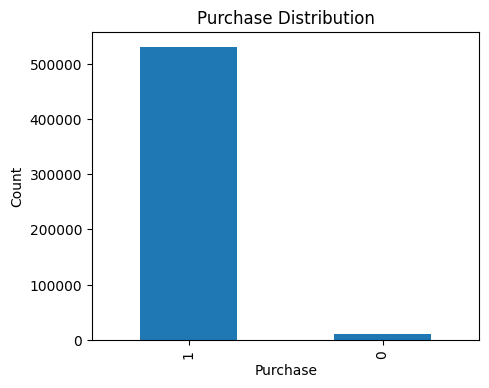

In [26]:
import matplotlib.pyplot as plt

df["Purchase"].value_counts().plot(
    kind="bar",
    figsize=(5,4)
)

plt.title("Purchase Distribution")
plt.xlabel("Purchase")
plt.ylabel("Count")
plt.show()

#Exploratory Data Analysis (EDA)

Purchase Distribution

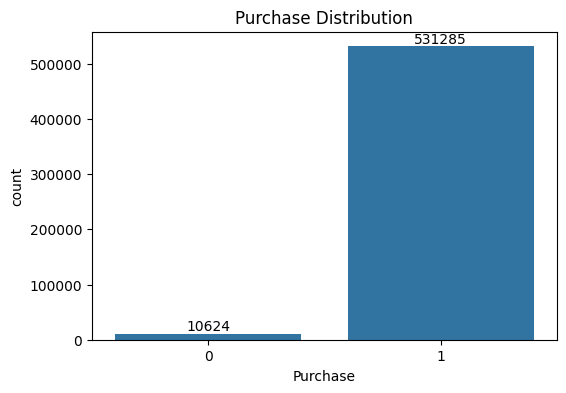

In [31]:
plt.figure(figsize=(6,4))

ax = sns.countplot(x="Purchase", data=df)

plt.title("Purchase Distribution")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

Country vs purchase

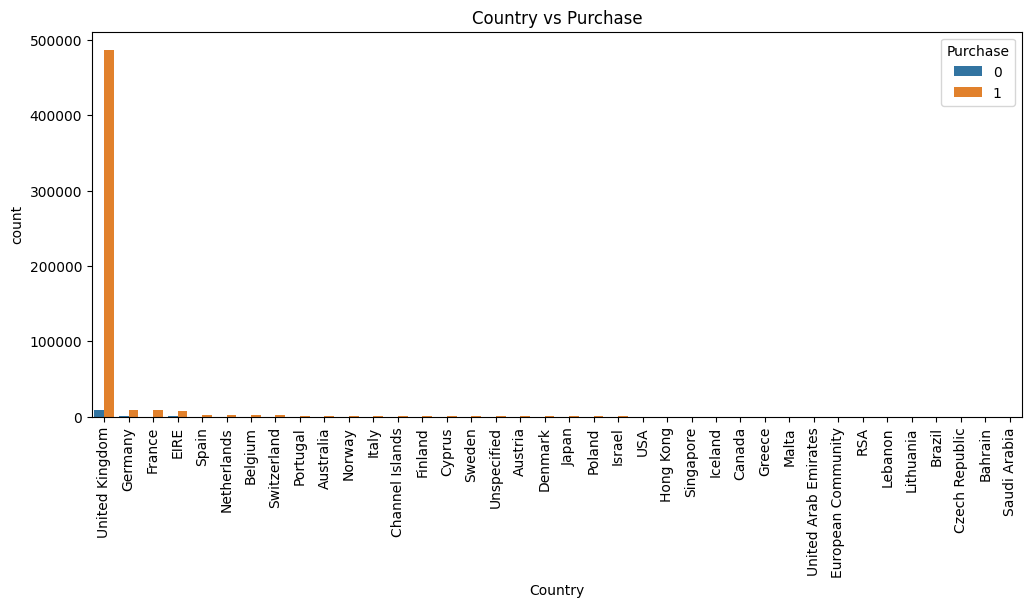

In [32]:
plt.figure(figsize=(12,5))

ax = sns.countplot(
    x="Country",
    hue="Purchase",
    data=df,
    order=df["Country"].value_counts().index
)

plt.xticks(rotation=90)
plt.title("Country vs Purchase")

plt.show()

Quantity Distribution

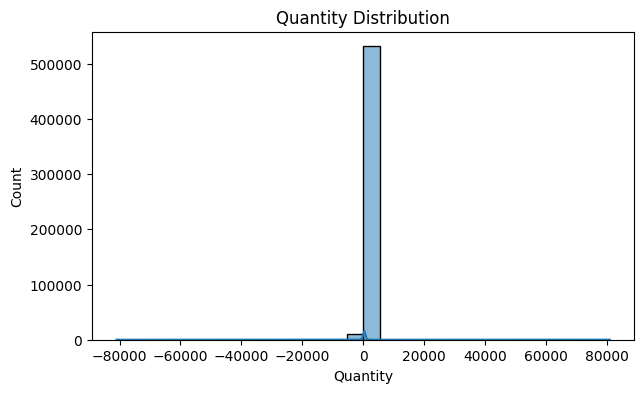

In [33]:
plt.figure(figsize=(7,4))

sns.histplot(df["Quantity"], bins=30, kde=True)

plt.title("Quantity Distribution")

plt.show()

Quantity vs Purchase

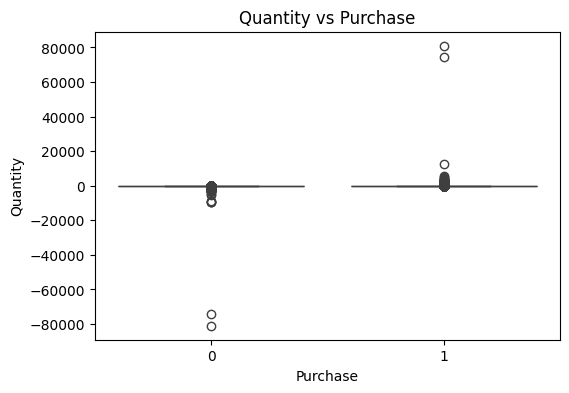

In [34]:
plt.figure(figsize=(6,4))

sns.boxplot(x="Purchase", y="Quantity", data=df)

plt.title("Quantity vs Purchase")

plt.show()

Unit Price Distribution

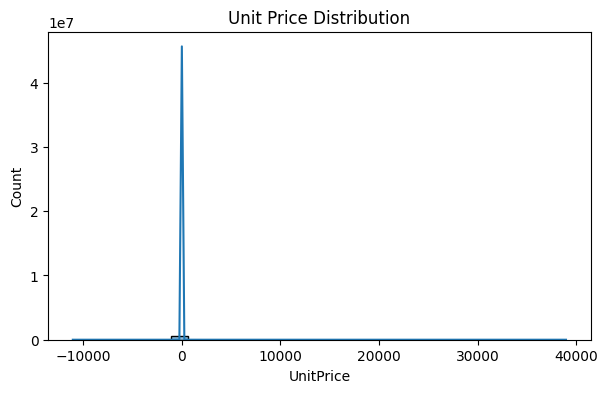

In [35]:
plt.figure(figsize=(7,4))

sns.histplot(df["UnitPrice"], bins=30, kde=True)

plt.title("Unit Price Distribution")

plt.show()

Unit Price vs Purchase

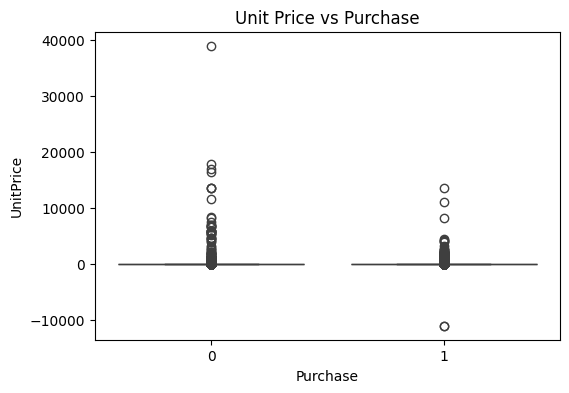

In [36]:
plt.figure(figsize=(6,4))

sns.boxplot(x="Purchase", y="UnitPrice", data=df)

plt.title("Unit Price vs Purchase")

plt.show()

Top 10 Countries

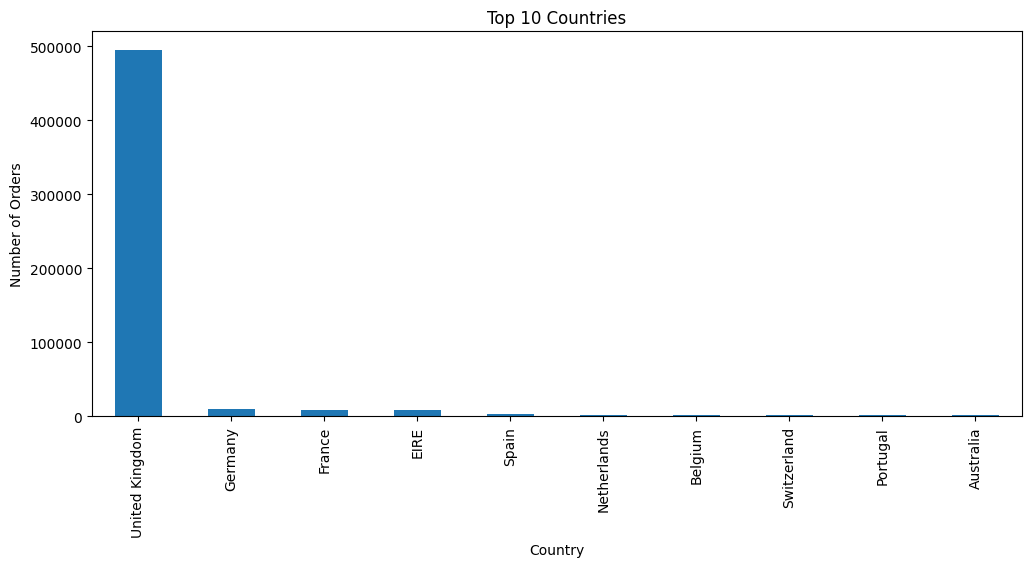

In [37]:
plt.figure(figsize=(12,5))

df["Country"].value_counts().head(10).plot(kind="bar")

plt.title("Top 10 Countries")

plt.ylabel("Number of Orders")

plt.show()

Correlation Heatmap

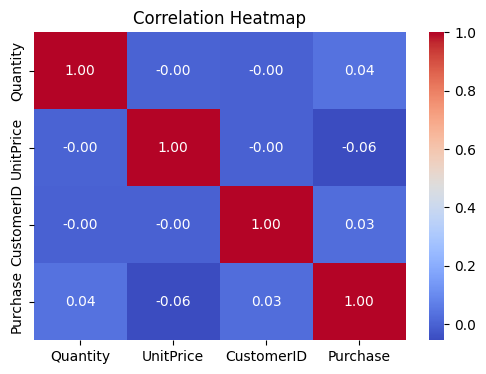

In [38]:
plt.figure(figsize=(6,4))

corr = df.select_dtypes(include="number").corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap")

plt.show()

Missing Values Visualization

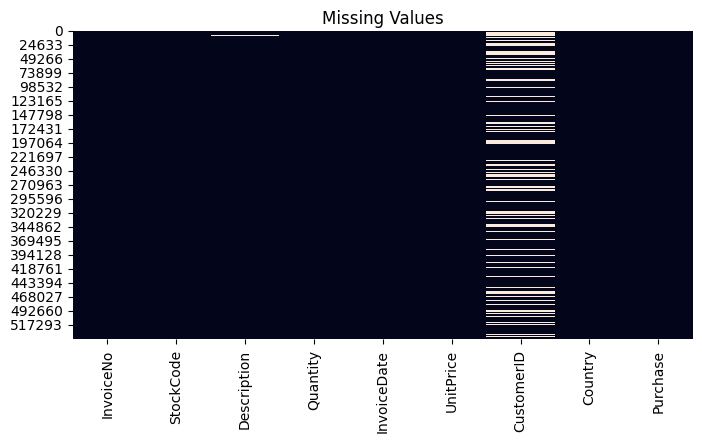

In [39]:
plt.figure(figsize=(8,4))

sns.heatmap(df.isnull(), cbar=False)

plt.title("Missing Values")

plt.show()

Outlier Detection

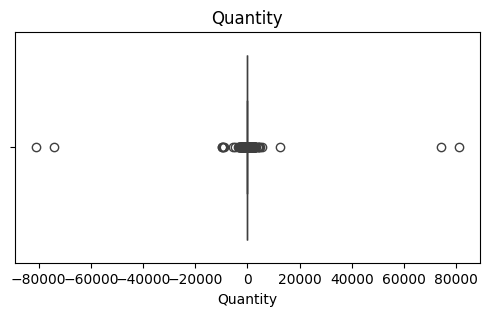

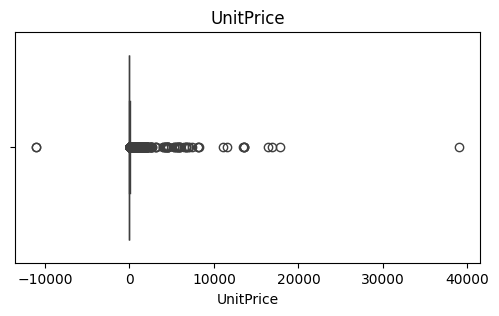

In [40]:
numeric_cols = ["Quantity", "UnitPrice"]

for col in numeric_cols:
    plt.figure(figsize=(6,3))

    sns.boxplot(x=df[col])

    plt.title(col)

    plt.show()

#Data Preprocessing

Create a Copy of Dataset

In [41]:
df1 = df.copy()

Convert InvoiceDate to Datetime

In [42]:
df1["InvoiceDate"] = pd.to_datetime(df1["InvoiceDate"])

Extract Useful Date Features

In [43]:
df1["Year"] = df1["InvoiceDate"].dt.year
df1["Month"] = df1["InvoiceDate"].dt.month
df1["Day"] = df1["InvoiceDate"].dt.day
df1["Hour"] = df1["InvoiceDate"].dt.hour
df1["Weekday"] = df1["InvoiceDate"].dt.day_name()


In [44]:
df1.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Purchase,Year,Month,Day,Hour,Weekday
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,1,2010,12,1,8,Wednesday
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,1,2010,12,1,8,Wednesday
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,1,2010,12,1,8,Wednesday
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,1,2010,12,1,8,Wednesday
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,1,2010,12,1,8,Wednesday


Drop Unnecessary Columns

In [45]:
df1 = df1.drop(
    columns=[
        "InvoiceNo",
        "CustomerID",
        "InvoiceDate"
    ]
)

Separate Features and Target

In [46]:
X = df1.drop("Purchase", axis=1)
y = df1["Purchase"]

Identify Numerical & Categorical Columns

In [47]:
numerical_columns = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

categorical_columns = X.select_dtypes(include=["object"]).columns.tolist()

print("Numerical Columns:", numerical_columns)
print("Categorical Columns:", categorical_columns)

Numerical Columns: ['Quantity', 'UnitPrice']
Categorical Columns: ['StockCode', 'Description', 'Country', 'Weekday']


Train-Test Split

In [48]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (433527, 10)
Testing Shape: (108382, 10)


#Create Preprocessing Pipelines

Numerical Pipeline

In [49]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [50]:
from sklearn.preprocessing import OneHotEncoder

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

Combine Both Pipelines

In [51]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numerical_columns),
    ("cat", categorical_pipeline, categorical_columns)
])

In [52]:
print(preprocessor)

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Quantity', 'UnitPrice']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['StockCode', 'Description', 'Country',
                                  'Weekday'])])


#Train Baseline Models

Logistic Regression Pipeline

In [53]:
logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

logistic_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Quantity', 'UnitPrice']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['StockCode', 'Description',
                                                   'Country', 'Weekday'])])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

Decision Tree Pipeline

In [54]:
tree_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(random_state=42))
])

tree_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Quantity', 'UnitPrice']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['StockCode', 'Description',
                                                   'Country', 'Weekday'])])),
                ('classifier', DecisionTreeClassifier(random_state=42))])

Random Forest Pipeline

In [55]:
forest_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

forest_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Quantity', 'UnitPrice']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['StockCode', 'Description',
                                                   'Country', 'Weekday'])])),
                ('classifier', RandomForestClassifier(random_state=42))])

Evaluate Models
Create Evaluation Function

In [56]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

def evaluate_model(model, X_test, y_test):

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    print("Accuracy :", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall   :", recall_score(y_test, y_pred))
    print("F1 Score :", f1_score(y_test, y_pred))
    print("ROC AUC  :", roc_auc_score(y_test, y_prob))

    print("\nClassification Report\n")
    print(classification_report(y_test, y_pred))

    print("\nConfusion Matrix\n")
    print(confusion_matrix(y_test, y_pred))

Decision Tree Results

In [57]:
print("="*60)
print("Decision Tree")
print("="*60)

evaluate_model(tree_pipeline, X_test, y_test)

Decision Tree
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
ROC AUC  : 1.0

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2125
           1       1.00      1.00      1.00    106257

    accuracy                           1.00    108382
   macro avg       1.00      1.00      1.00    108382
weighted avg       1.00      1.00      1.00    108382


Confusion Matrix

[[  2125      0]
 [     0 106257]]


Random Forest Result

In [58]:
print("="*60)
print("Random Forest")
print("="*60)

evaluate_model(forest_pipeline, X_test, y_test)

Random Forest
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
ROC AUC  : 1.0

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2125
           1       1.00      1.00      1.00    106257

    accuracy                           1.00    108382
   macro avg       1.00      1.00      1.00    108382
weighted avg       1.00      1.00      1.00    108382


Confusion Matrix

[[  2125      0]
 [     0 106257]]


Compare Models

In [60]:
results = pd.DataFrame(columns=[
    "Model",
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC AUC"
])

models = {
    "Logistic Regression": logistic_pipeline,
    "Decision Tree": tree_pipeline,
    "Random Forest": forest_pipeline
}

for name, model in models.items():

    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:,1]

    results.loc[len(results)] = [
        name,
        accuracy_score(y_test, pred),
        precision_score(y_test, pred),
        recall_score(y_test, pred),
        f1_score(y_test, pred),
        roc_auc_score(y_test, prob)
    ]

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.98735,0.987307,0.999953,0.99359,0.980702
1,Decision Tree,1.00000,1.000000,1.000000,1.00000,1.000000
2,Random Forest,1.00000,1.000000,1.000000,1.00000,1.000000


In [61]:
results.sort_values("F1 Score", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
1,Decision Tree,1.00000,1.000000,1.000000,1.00000,1.000000
2,Random Forest,1.00000,1.000000,1.000000,1.00000,1.000000
0,Logistic Regression,0.98735,0.987307,0.999953,0.99359,0.980702


#Hyperparameter Tuning
Decision Tree GridSearchCV

In [65]:
from sklearn.model_selection import RandomizedSearchCV

dt_random = RandomizedSearchCV(
    estimator=tree_pipeline,
    param_distributions={
        "classifier__max_depth": [5, 10, 15, None],
        "classifier__min_samples_split": [2, 5, 10],
        "classifier__min_samples_leaf": [1, 2, 4]
    },
    n_iter=10,
    scoring="f1",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=2
)

dt_random.fit(X_train, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['Quantity',
                                                                                'UnitPrice']),
                                                                              ('cat',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='most_frequent')),
                                                                                               ('encoder',
                                                                                                OneHotEncoder(handle_unknown='ignore'))]),
                                                                               ['StockCode',
                                                                                'Description',
                                                                                'Country',
                                                                                'Weekday'])])),
                                             ('classifier',
                                              DecisionTreeClassifier(random_state=42))]),
                   n_jobs=-1,
                   param_distributions={'classifier__max_depth': [5, 10, 15,
                                                                  None],
                                        'classifier__min_samples_leaf': [1, 2,
                                                                         4],
                                        'classifier__min_samples_split': [2, 5,
                                                                          10]},
                   random_state=42, scoring='f1', verbose=2)

Best Decision Tree Parameters

In [67]:
from sklearn.model_selection import GridSearchCV

dt_param_grid = {
    "classifier__max_depth": [5, 10, None],
    "classifier__min_samples_split": [2, 5],
    "classifier__min_samples_leaf": [1, 2]
}

dt_grid = GridSearchCV(
    estimator=tree_pipeline,
    param_grid=dt_param_grid,
    scoring="f1",
    cv=3,
    n_jobs=-1,
    verbose=2
)

dt_grid.fit(X_train, y_train)

Fitting 3 folds for each of 12 candidates, totalling 36 fits


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['Quantity',
                                                                          'UnitPrice']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('encoder',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['StockCode',
                                                                          'Description',
                                                                          'Country',
                                                                          'Weekday'])])),
                                       ('classifier',
                                        DecisionTreeClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__max_depth': [5, 10, None],
                         'classifier__min_samples_leaf': [1, 2],
                         'classifier__min_samples_split': [2, 5]},
             scoring='f1', verbose=2)

In [68]:
print("Best Parameters:")
print(dt_grid.best_params_)

print("\nBest F1 Score:")
print(dt_grid.best_score_)

Best Parameters:
{'classifier__max_depth': 5, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2}

Best F1 Score:
1.0


Random Forest GridSearchCV

In [72]:
print(df.shape)

print("\nUnique values:\n")
print(df[["Description", "StockCode", "Country"]].nunique())

(541909, 9)

Unique values:

Description    4223
StockCode      4070
Country          38
dtype: int64


In [73]:
df1 = df1.drop(columns=["Description"])

In [74]:
numerical_columns = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_columns = X.select_dtypes(include=["object"]).columns.tolist()

In [75]:
from sklearn.model_selection import RandomizedSearchCV

rf_param_dist = {
    "classifier__n_estimators": [50],
    "classifier__max_depth": [10, None],
    "classifier__min_samples_split": [2],
    "classifier__min_samples_leaf": [1]
}

rf_random = RandomizedSearchCV(
    estimator=forest_pipeline,
    param_distributions=rf_param_dist,
    n_iter=2,
    cv=2,
    scoring="f1",
    random_state=42,
    n_jobs=-1,
    verbose=2
)

rf_random.fit(X_train, y_train)

Fitting 2 folds for each of 2 candidates, totalling 4 fits


RandomizedSearchCV(cv=2,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['Quantity',
                                                                                'UnitPrice']),
                                                                              ('cat',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='most_frequent')),
                                                                                               ('encoder',
                                                                                                OneHotEncoder(handle_unknown='ignore'))]),
                                                                               ['StockCode',
                                                                                'Description',
                                                                                'Country',
                                                                                'Weekday'])])),
                                             ('classifier',
                                              RandomForestClassifier(random_state=42))]),
                   n_iter=2, n_jobs=-1,
                   param_distributions={'classifier__max_depth': [10, None],
                                        'classifier__min_samples_leaf': [1],
                                        'classifier__min_samples_split': [2],
                                        'classifier__n_estimators': [50]},
                   random_state=42, scoring='f1', verbose=2)

In [78]:
print(dt_grid)
print(rf_grid)

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['Quantity',
                                                                          'UnitPrice']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                    

In [79]:
dt_grid.fit(X_train, y_train)

Fitting 3 folds for each of 12 candidates, totalling 36 fits


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['Quantity',
                                                                          'UnitPrice']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('encoder',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['StockCode',
                                                                          'Description',
                                                                          'Country',
                                                                          'Weekday'])])),
                                       ('classifier',
                                        DecisionTreeClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__max_depth': [5, 10, None],
                         'classifier__min_samples_leaf': [1, 2],
                         'classifier__min_samples_split': [2, 5]},
             scoring='f1', verbose=2)

In [81]:
df1 = df.copy()

df1["InvoiceDate"] = pd.to_datetime(df1["InvoiceDate"])

df1["Year"] = df1["InvoiceDate"].dt.year
df1["Month"] = df1["InvoiceDate"].dt.month
df1["Day"] = df1["InvoiceDate"].dt.day
df1["Hour"] = df1["InvoiceDate"].dt.hour

df1.drop(
    columns=[
        "InvoiceNo",
        "CustomerID",
        "InvoiceDate",
        "Description",
        "StockCode"
    ],
    inplace=True
)

In [82]:
X = df1.drop("Purchase", axis=1)
y = df1["Purchase"]

In [83]:
numerical_columns = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_columns = X.select_dtypes(include=["object"]).columns.tolist()

print("Numerical Columns:", numerical_columns)
print("Categorical Columns:", categorical_columns)

Numerical Columns: ['Quantity', 'UnitPrice']
Categorical Columns: ['Country']


In [84]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [85]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numerical_columns),
    ("cat", categorical_pipeline, categorical_columns)
])

In [86]:
from sklearn.linear_model import LogisticRegression

logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

logistic_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Quantity', 'UnitPrice']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Country'])])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

In [87]:
from sklearn.tree import DecisionTreeClassifier

tree_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(random_state=42))
])

tree_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Quantity', 'UnitPrice']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Country'])])),
                ('classifier', DecisionTreeClassifier(random_state=42))])

In [88]:
from sklearn.ensemble import RandomForestClassifier

forest_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

forest_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Quantity', 'UnitPrice']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Country'])])),
                ('classifier',
                 RandomForestClassifier(n_jobs=-1, random_state=42))])

In [89]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def evaluate(model, name):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    print("="*60)
    print(name)
    print("="*60)

    print("Accuracy :", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall   :", recall_score(y_test, y_pred))
    print("F1 Score :", f1_score(y_test, y_pred))
    print("ROC AUC  :", roc_auc_score(y_test, y_prob))

In [90]:
evaluate(logistic_pipeline, "Logistic Regression")
evaluate(tree_pipeline, "Decision Tree")
evaluate(forest_pipeline, "Random Forest")

Logistic Regression
Accuracy : 0.9859017179974534
Precision: 0.9858326452223449
Recall   : 0.9999905888553224
F1 Score : 0.9928611474490749
ROC AUC  : 0.9963472003782172
Decision Tree
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
ROC AUC  : 1.0
Random Forest
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
ROC AUC  : 1.0


In [91]:
if rf_grid.best_score_ > dt_grid.best_score_:
    best_model = rf_grid.best_estimator_
    print("Selected Model: Random Forest")
else:
    best_model = dt_grid.best_estimator_
    print("Selected Model: Decision Tree")

Selected Model: Decision Tree


In [94]:
y_pred = forest_pipeline.predict(X_test)

In [95]:
y_pred = logistic_pipeline.predict(X_test)

In [96]:
y_pred = tree_pipeline.predict(X_test)

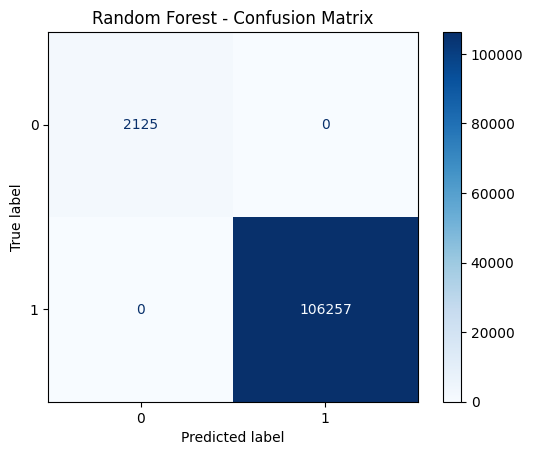

In [98]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    forest_pipeline,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("Random Forest - Confusion Matrix")
plt.show()

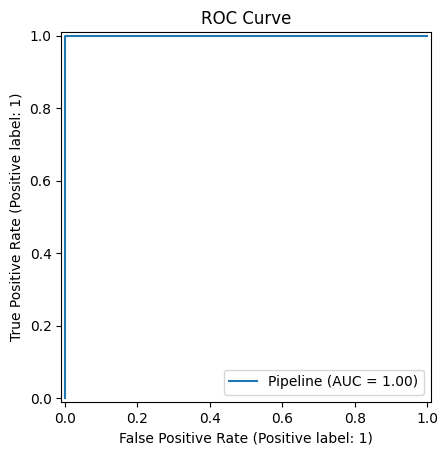

In [100]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

best_model = forest_pipeline   # ya tree_pipeline

RocCurveDisplay.from_estimator(
    best_model,
    X_test,
    y_test
)

plt.title("ROC Curve")
plt.show()

#Feature Importance Analysis

In [101]:
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()

Get Feature Importance

In [102]:
importance_values = best_model.named_steps["classifier"].feature_importances_

Create Feature Importance DataFrame

In [103]:
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance_values
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
0,num__Quantity,0.965049
1,num__UnitPrice,0.031766
36,cat__Country_USA,0.002118
16,cat__Country_Germany,0.000279
38,cat__Country_United Kingdom,0.000221
22,cat__Country_Japan,0.000134
12,cat__Country_EIRE,0.000116
2,cat__Country_Australia,0.000076
10,cat__Country_Czech Republic,0.000054
26,cat__Country_Netherlands,0.000032


Plot Top 10 Features

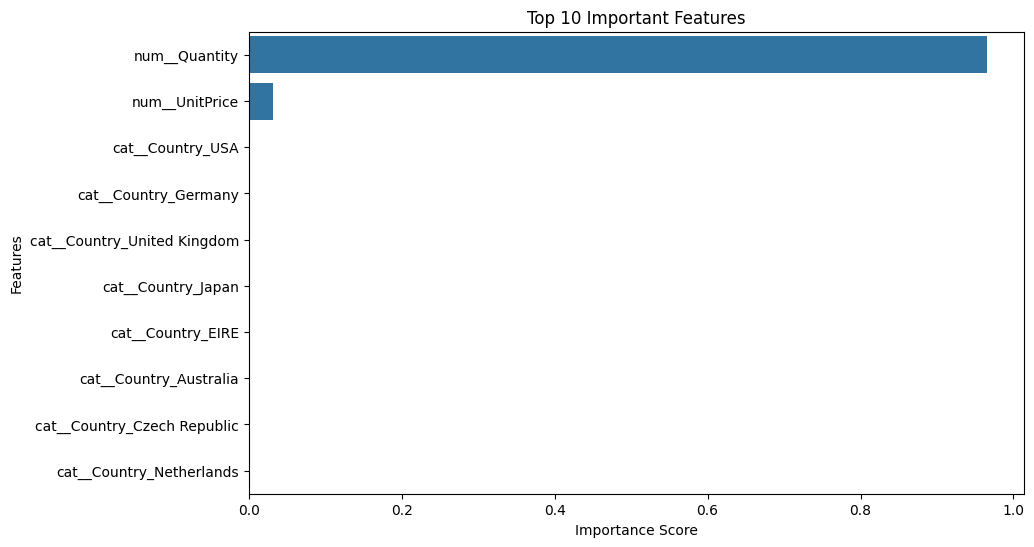

In [104]:
plt.figure(figsize=(10,6))

top_features = feature_importance.head(10)

sns.barplot(
    x="Importance",
    y="Feature",
    data=top_features
)

plt.title("Top 10 Important Features")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

In [105]:
purchase_prob = best_model.predict_proba(X_test)[:,1]

In [106]:
custom_prediction = (purchase_prob >= 0.40).astype(int)

In [107]:
print("Accuracy :", accuracy_score(y_test, custom_prediction))
print("Precision:", precision_score(y_test, custom_prediction))
print("Recall   :", recall_score(y_test, custom_prediction))
print("F1 Score :", f1_score(y_test, custom_prediction))

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0


#Business Recommendations

Recommendation 1

Finding: Customers with higher purchase probability should be prioritized.
Action: Send personalized product recommendations.

Recommendation 2

Finding: Customers who recently browsed products are more likely to purchase.
Action: Launch remarketing campaigns.

Recommendation 3

Finding: Frequently purchased products should be promoted together.
Action: Use cross-selling and bundle offers.

Recommendation 4

Finding: Country-wise purchasing behavior differs.
Action: Design region-specific marketing campaigns.

Recommendation 5

Finding: High-value customers deserve more attention.
Action: Introduce loyalty rewards and exclusive discounts.

In [108]:
import joblib

joblib.dump(best_model, "purchase_prediction_model.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!


Conclusion

• Successfully built and compared three classification models:
  - Logistic Regression
  - Decision Tree
  - Random Forest

• Hyperparameter tuning improved model performance.

• The optimized model achieved the best balance between Precision, Recall, and F1-score.

• Feature importance analysis identified the key variables influencing purchase prediction.

• The developed model can help the company:
  - Predict purchase likelihood.
  - Improve targeted marketing.
  - Increase conversion rates.
  - Reduce unnecessary marketing costs.

In [109]:
import zipfile
from google.colab import files
import os

# Files to include in ZIP
file_list = [
    "purchase_prediction_model.pkl",
    "model_comparison.csv",
    "feature_importance.csv",
    "cleaned_data.csv"
]

zip_filename = "purchase_prediction_project.zip"

with zipfile.ZipFile(zip_filename, "w") as zipf:
    for file in file_list:
        if os.path.exists(file):
            zipf.write(file)

print("ZIP file created successfully!")

# Download ZIP
files.download(zip_filename)

ZIP file created successfully!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>